In [1]:
from google.colab import files
uploaded = files.upload()

Saving BC3412_Oyster_DTA_Analysis (2).py to BC3412_Oyster_DTA_Analysis (2).py
Saving cmems_mod_glo_bgc_my_0.25deg_P1M-m_1774961638008.nc to cmems_mod_glo_bgc_my_0.25deg_P1M-m_1774961638008.nc
Saving cmems_obs-mob_glo_phy_my_0.125deg_P1M-m_1774962702999.nc to cmems_obs-mob_glo_phy_my_0.125deg_P1M-m_1774962702999.nc


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Oyster_Histopath (1995-2010).csv to Oyster_Histopath (1995-2010).csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Marine_Microplastics_Oysters (1989-2016).csv to Marine_Microplastics_Oysters (1989-2016).csv


In [4]:
import os
print(os.listdir())

['.config', 'Oyster_Histopath (1995-2010).csv', 'BC3412_Oyster_DTA_Analysis (2).py', 'cmems_obs-mob_glo_phy_my_0.125deg_P1M-m_1774962702999.nc', 'cmems_mod_glo_bgc_my_0.25deg_P1M-m_1774961638008.nc', 'Marine_Microplastics_Oysters (1989-2016).csv', 'sample_data']


In [5]:
import pandas as pd
import xarray as xr

# CSV files
oy = pd.read_csv('Oyster_Histopath (1995-2010).csv')
mp = pd.read_csv('Marine_Microplastics_Oysters (1989-2016).csv')

# NetCDF files
bgc = xr.open_dataset('cmems_mod_glo_bgc_my_0.25deg_P1M-m_1774961638008.nc')
phy = xr.open_dataset('cmems_obs-mob_glo_phy_my_0.125deg_P1M-m_1774962702999.nc')

print("Oyster shape:", oy.shape)
print("MP shape:", mp.shape)

print("\nBGC variables:", list(bgc.data_vars))
print("PHY variables:", list(phy.data_vars))

Oyster shape: (3638, 71)
MP shape: (3191, 36)

BGC variables: ['no3', 'o2', 'ph']
PHY variables: ['so', 'to']


In [6]:
print("=== BGC DATASET ===")
print(bgc)

print("\n=== PHY DATASET ===")
print(phy)

=== BGC DATASET ===
<xarray.Dataset> Size: 8MB
Dimensions:    (time: 192, depth: 1, latitude: 77, longitude: 45)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1995-01-01 1995-02-01 ... 2010-12-01
  * depth      (depth) float32 4B 0.5058
  * latitude   (latitude) float32 308B 23.0 23.25 23.5 23.75 ... 41.5 41.75 42.0
  * longitude  (longitude) float32 180B -84.0 -83.75 -83.5 ... -73.25 -73.0
Data variables:
    no3        (time, depth, latitude, longitude) float32 3MB ...
    o2         (time, depth, latitude, longitude) float32 3MB ...
    ph         (time, depth, latitude, longitude) float32 3MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_BIO_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR FREEBIORYS2V4
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           service

In [7]:
# Convert BGC to dataframe
bgc_df = bgc.to_dataframe().reset_index()

# Convert PHY to dataframe
phy_df = phy.to_dataframe().reset_index()

print("BGC df shape:", bgc_df.shape)
print("PHY df shape:", phy_df.shape)

print("\nBGC columns:", bgc_df.columns.tolist())
print("PHY columns:", phy_df.columns.tolist())

print("\nBGC sample:")
print(bgc_df.head())

print("\nPHY sample:")
print(phy_df.head())

BGC df shape: (665280, 7)
PHY df shape: (2568192, 6)

BGC columns: ['time', 'depth', 'latitude', 'longitude', 'no3', 'o2', 'ph']
PHY columns: ['time', 'depth', 'latitude', 'longitude', 'so', 'to']

BGC sample:
        time    depth  latitude  longitude       no3          o2        ph
0 1995-01-01  0.50576      23.0     -84.00  0.009020  205.077759  8.091608
1 1995-01-01  0.50576      23.0     -83.75  0.006564  205.056458  8.091874
2 1995-01-01  0.50576      23.0     -83.50  0.006045  205.031815  8.091578
3 1995-01-01  0.50576      23.0     -83.25  0.006510  205.020126  8.091409
4 1995-01-01  0.50576      23.0     -83.00  0.007682  205.889496  8.095358

PHY sample:
        time  depth  latitude  longitude         so         to
0 1995-01-01   -0.0   23.0625   -83.9375  35.977001  26.014999
1 1995-01-01   -0.0   23.0625   -83.8125  35.978001  26.002001
2 1995-01-01   -0.0   23.0625   -83.6875  35.980999  26.000999
3 1995-01-01   -0.0   23.0625   -83.5625  35.984001  26.003000
4 1995-01-01

In [9]:
# Add year column
bgc_df['year'] = pd.to_datetime(bgc_df['time']).dt.year
phy_df['year'] = pd.to_datetime(phy_df['time']).dt.year

print("BGC years:", bgc_df['year'].min(), "to", bgc_df['year'].max())
print("PHY years:", phy_df['year'].min(), "to", phy_df['year'].max())

print("\nBGC columns:", bgc_df.columns.tolist())
print("PHY columns:", phy_df.columns.tolist())

BGC years: 1995 to 2010
PHY years: 1995 to 2010

BGC columns: ['time', 'latitude', 'longitude', 'no3', 'o2', 'ph', 'year']
PHY columns: ['time', 'latitude', 'longitude', 'so', 'to', 'year']


In [10]:
# Create oyster site table
sites = oy.groupby(['General Location', 'Latitude', 'Longitude', 'State Name']).agg(
    n_oysters=('NST_Sample_ID', 'count'),
    year_min=('Fiscal Year', 'min'),
    year_max=('Fiscal Year', 'max')
).reset_index()

print("Number of oyster sites:", len(sites))
print(sites.head())

Number of oyster sites: 32
  General Location  Latitude  Longitude      State Name  n_oysters  year_min  \
0   Beaufort Inlet   34.7183   -76.6755  North Carolina         96      1996   
1     Biscayne Bay   25.5333   -80.3232         Florida         84      1995   
2        Cape Fear   33.9158   -78.0035  North Carolina        126      1988   
3   Chesapeake Bay   37.0653   -76.6322        Virginia         96      1995   
4   Chesapeake Bay   37.0983   -76.2948        Virginia        126      1988   

   year_max  
0      2010  
1      2007  
2      2010  
3      2009  
4      2009  


In [11]:
RADIUS = 1.0  # same as your MP code

bgc_site_list = []

for _, site in sites.iterrows():
    lat, lon = site['Latitude'], site['Longitude']

    nearby = bgc_df[
        (abs(bgc_df['latitude'] - lat) <= RADIUS) &
        (abs(bgc_df['longitude'] - lon) <= RADIUS)
    ].copy()

    if len(nearby) > 0:
        nearby['General Location'] = site['General Location']
        bgc_site_list.append(nearby)

bgc_site = pd.concat(bgc_site_list, ignore_index=True)

# Aggregate yearly
bgc_annual = bgc_site.groupby(['General Location', 'year']).agg(
    no3_mean=('no3', 'mean'),
    o2_mean=('o2', 'mean'),
    ph_mean=('ph', 'mean')
).reset_index()

print("BGC annual shape:", bgc_annual.shape)
print(bgc_annual.head())

BGC annual shape: (256, 5)
  General Location  year  no3_mean     o2_mean   ph_mean
0   Beaufort Inlet  1995  0.283852  219.507339  8.116522
1   Beaufort Inlet  1996  0.195655  220.606613  8.120214
2   Beaufort Inlet  1997  0.196525  217.879700  8.115240
3   Beaufort Inlet  1998  0.231406  218.847351  8.106975
4   Beaufort Inlet  1999  0.198849  217.007782  8.113458


In [12]:
phy_site_list = []

for _, site in sites.iterrows():
    lat, lon = site['Latitude'], site['Longitude']

    nearby = phy_df[
        (abs(phy_df['latitude'] - lat) <= RADIUS) &
        (abs(phy_df['longitude'] - lon) <= RADIUS)
    ].copy()

    if len(nearby) > 0:
        nearby['General Location'] = site['General Location']
        phy_site_list.append(nearby)

phy_site = pd.concat(phy_site_list, ignore_index=True)

# Aggregate yearly
phy_annual = phy_site.groupby(['General Location', 'year']).agg(
    temp_mean=('to', 'mean'),
    sal_mean=('so', 'mean')
).reset_index()

print("PHY annual shape:", phy_annual.shape)
print(phy_annual.head())

PHY annual shape: (256, 4)
  General Location  year  temp_mean   sal_mean
0   Beaufort Inlet  1995  22.870718  35.522335
1   Beaufort Inlet  1996  22.045994  35.564579
2   Beaufort Inlet  1997  22.354666  35.422970
3   Beaufort Inlet  1998  22.291298  35.253914
4   Beaufort Inlet  1999  22.656956  35.524849


In [13]:
# First merge BGC + PHY together
env_annual = pd.merge(
    bgc_annual,
    phy_annual,
    on=['General Location', 'year'],
    how='inner'
)

print("Env combined shape:", env_annual.shape)
print(env_annual.head())

Env combined shape: (256, 7)
  General Location  year  no3_mean     o2_mean   ph_mean  temp_mean   sal_mean
0   Beaufort Inlet  1995  0.283852  219.507339  8.116522  22.870718  35.522335
1   Beaufort Inlet  1996  0.195655  220.606613  8.120214  22.045994  35.564579
2   Beaufort Inlet  1997  0.196525  217.879700  8.115240  22.354666  35.422970
3   Beaufort Inlet  1998  0.231406  218.847351  8.106975  22.291298  35.253914
4   Beaufort Inlet  1999  0.198849  217.007782  8.113458  22.656956  35.524849


In [14]:
# Merge with oyster dataset
oy_env = oy.merge(
    env_annual.rename(columns={'year': 'Fiscal Year'}),
    on=['General Location', 'Fiscal Year'],
    how='inner'
)

print("Final merged dataset shape:", oy_env.shape)
print(oy_env.head())

Final merged dataset shape: (2639, 76)
          Study NST_Site General Location Specific Location State Name  \
0  Mussel Watch     BBGC     Biscayne Bay     Gould's Canal    Florida   
1  Mussel Watch     BBGC     Biscayne Bay     Gould's Canal    Florida   
2  Mussel Watch     BBGC     Biscayne Bay     Gould's Canal    Florida   
3  Mussel Watch     BBGC     Biscayne Bay     Gould's Canal    Florida   
4  Mussel Watch     BBGC     Biscayne Bay     Gould's Canal    Florida   

       Region                Specific Region         Coastal Ecological Area  \
0  East Coast  Florida Keys to Cape Hatteras  Central and South Biscayne Bay   
1  East Coast  Florida Keys to Cape Hatteras  Central and South Biscayne Bay   
2  East Coast  Florida Keys to Cape Hatteras  Central and South Biscayne Bay   
3  East Coast  Florida Keys to Cape Hatteras  Central and South Biscayne Bay   
4  East Coast  Florida Keys to Cape Hatteras  Central and South Biscayne Bay   

   Latitude  Longitude  ... Protozo

In [16]:
# Convert MP date to datetime and extract year
mp['Sample Date'] = pd.to_datetime(mp['Sample Date'], format='mixed')
mp['year'] = mp['Sample Date'].dt.year

# Match MP to oyster sites (same logic as before)
RADIUS = 1.0

site_mp_list = []

for _, site in sites.iterrows():
    lat, lon = site['Latitude'], site['Longitude']

    nearby = mp[
        (abs(mp['Latitude (degree)'] - lat) <= RADIUS) &
        (abs(mp['Longitude (degree)'] - lon) <= RADIUS)
    ].copy()

    if len(nearby) > 0:
        nearby['General Location'] = site['General Location']
        site_mp_list.append(nearby)

site_mp = pd.concat(site_mp_list, ignore_index=True)

# Aggregate yearly MP
site_mp_annual = site_mp.groupby(['General Location', 'year']).agg(
    mp_mean=('Microplastics Measurement', 'mean'),
    mp_count=('Microplastics Measurement', 'count')
).reset_index()

print("MP annual shape:", site_mp_annual.shape)
print(site_mp_annual.head())

MP annual shape: (83, 4)
  General Location  year   mp_mean  mp_count
0   Beaufort Inlet  2015  0.323000         1
1     Biscayne Bay  1991  0.000000         2
2     Biscayne Bay  1992  0.001254         5
3     Biscayne Bay  1993  0.001080         2
4     Biscayne Bay  1994  0.000000         6


In [17]:
oy_full = oy_env.merge(
    site_mp_annual.rename(columns={'year': 'Fiscal Year'}),
    on=['General Location', 'Fiscal Year'],
    how='inner'
)

print("Full dataset shape:", oy_full.shape)

Full dataset shape: (287, 78)


In [18]:
print("Unique years:", oy_full['Fiscal Year'].nunique())
print("Unique sites:", oy_full['General Location'].nunique())

print("\nRows per year:")
print(oy_full['Fiscal Year'].value_counts().sort_index())

Unique years: 8
Unique sites: 7

Rows per year:
Fiscal Year
1995    35
1997    36
1999    36
2001    36
2003    24
2005    60
2007    24
2008    36
Name: count, dtype: int64


In [19]:
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Keep simple first
predictors = ['mp_mean', 'temp_mean', 'sal_mean']

model_df = oy_full[['Digestive Tubule Atrophy'] + predictors].dropna().copy()

model_df['dta'] = model_df['Digestive Tubule Atrophy'].astype(int)

X = model_df[predictors]
y = model_df['dta']

ord_basic = OrderedModel(y, X, distr='logit').fit(method='bfgs', disp=0)

print(ord_basic.summary())

print("\nOdds ratios:")
for var in predictors:
    coef = ord_basic.params[var]
    print(f"{var}: coef = {coef:.4f}, OR = {np.exp(coef):.4f}, p = {ord_basic.pvalues[var]:.6f}")

                             OrderedModel Results                             
Dep. Variable:                    dta   Log-Likelihood:                -160.99
Model:                   OrderedModel   AIC:                             336.0
Method:            Maximum Likelihood   BIC:                             355.5
Date:                Tue, 31 Mar 2026                                         
Time:                        13:39:51                                         
No. Observations:                 120                                         
Df Residuals:                     113                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
mp_mean        6.8380     21.190      0.323      0.747     -34.693      48.370
temp_mean      0.2800      0.241      1.161      0.2

In [20]:
predictors = ['mp_mean', 'temp_mean', 'sal_mean', 'o2_mean', 'ph_mean']

model_df = oy_full[['Digestive Tubule Atrophy'] + predictors].dropna().copy()

model_df['dta'] = model_df['Digestive Tubule Atrophy'].astype(int)

print("Observations used:", len(model_df))

X = model_df[predictors]
y = model_df['dta']

ord_env = OrderedModel(y, X, distr='logit').fit(method='bfgs', disp=0)

print(ord_env.summary())

print("\nOdds ratios:")
for var in predictors:
    coef = ord_env.params[var]
    print(f"{var}: coef = {coef:.4f}, OR = {np.exp(coef):.4f}, p = {ord_env.pvalues[var]:.6f}")

Observations used: 120
                             OrderedModel Results                             
Dep. Variable:                    dta   Log-Likelihood:                -157.22
Model:                   OrderedModel   AIC:                             332.4
Method:            Maximum Likelihood   BIC:                             357.5
Date:                Tue, 31 Mar 2026                                         
Time:                        13:41:44                                         
No. Observations:                 120                                         
Df Residuals:                     111                                         
Df Model:                           5                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
mp_mean       -6.7877     23.838     -0.285      0.776     -53.509      39.933
temp_mean     -0.0250      0.

In [21]:
predictors = ['mp_mean', 'temp_mean', 'sal_mean', 'o2_mean', 'ph_mean', 'no3_mean']

model_df = oy_full[['Digestive Tubule Atrophy'] + predictors].dropna().copy()

model_df['dta'] = model_df['Digestive Tubule Atrophy'].astype(int)

print("Observations used:", len(model_df))

X = model_df[predictors]
y = model_df['dta']

ord_full = OrderedModel(y, X, distr='logit').fit(method='bfgs', disp=0)

print(ord_full.summary())

print("\nOdds ratios:")
for var in predictors:
    coef = ord_full.params[var]
    print(f"{var}: coef = {coef:.4f}, OR = {np.exp(coef):.4f}, p = {ord_full.pvalues[var]:.6f}")

Observations used: 120
                             OrderedModel Results                             
Dep. Variable:                    dta   Log-Likelihood:                -157.19
Model:                   OrderedModel   AIC:                             334.4
Method:            Maximum Likelihood   BIC:                             362.3
Date:                Tue, 31 Mar 2026                                         
Time:                        13:43:49                                         
No. Observations:                 120                                         
Df Residuals:                     110                                         
Df Model:                           6                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
mp_mean       -8.9642     25.092     -0.357      0.721     -58.144      40.216
temp_mean     -0.0534      0.

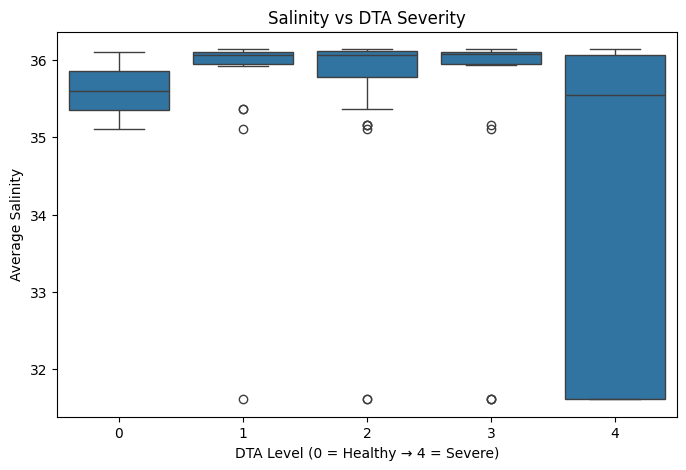

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
plot_df = oy_full[['Digestive Tubule Atrophy', 'sal_mean']].dropna().copy()
plot_df['dta'] = plot_df['Digestive Tubule Atrophy'].astype(int)

plt.figure(figsize=(8,5))
sns.boxplot(x='dta', y='sal_mean', data=plot_df)

plt.title('Salinity vs DTA Severity')
plt.xlabel('DTA Level (0 = Healthy → 4 = Severe)')
plt.ylabel('Average Salinity')

plt.show()

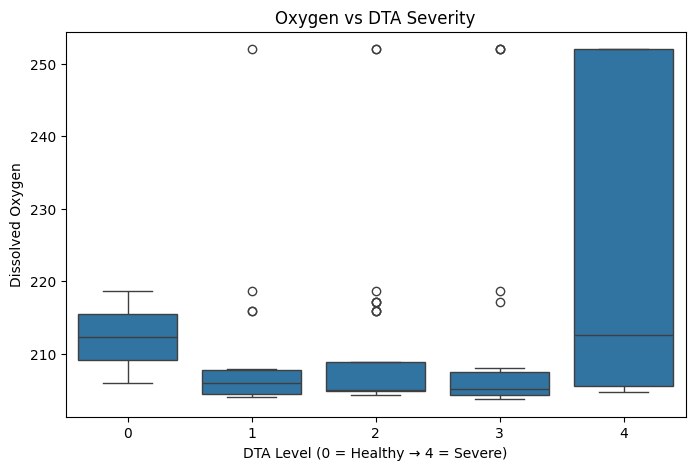

In [23]:
plot_df2 = oy_full[['Digestive Tubule Atrophy', 'o2_mean']].dropna().copy()
plot_df2['dta'] = plot_df2['Digestive Tubule Atrophy'].astype(int)

plt.figure(figsize=(8,5))
sns.boxplot(x='dta', y='o2_mean', data=plot_df2)

plt.title('Oxygen vs DTA Severity')
plt.xlabel('DTA Level (0 = Healthy → 4 = Severe)')
plt.ylabel('Dissolved Oxygen')

plt.show()

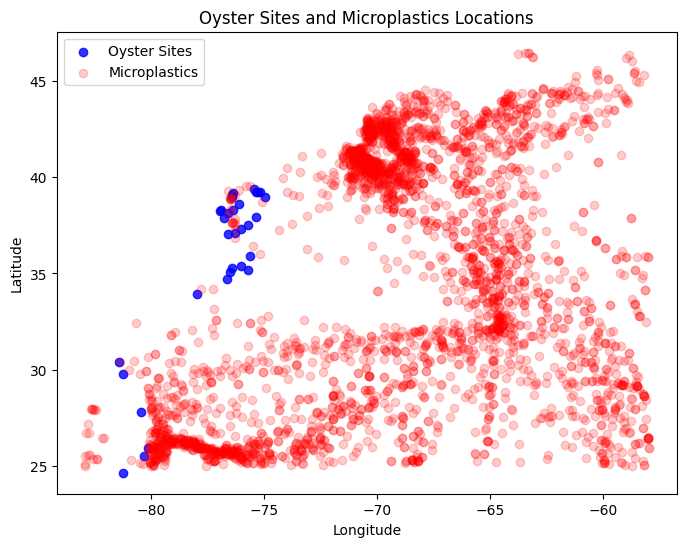

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Oyster sites
plt.scatter(
    sites['Longitude'],
    sites['Latitude'],
    c='blue',
    label='Oyster Sites',
    alpha=0.8
)

# OPTIONAL: Microplastics points (comment out if too messy)
plt.scatter(
    mp['Longitude (degree)'],
    mp['Latitude (degree)'],
    c='red',
    label='Microplastics',
    alpha=0.2
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Oyster Sites and Microplastics Locations')

plt.legend()
plt.show()